#  Feature Engineering Notebook  
## Turning Customer Information into ML-Ready Features

In the previous notebooks, we cleaned the data, merged customer application details with credit history, and explored important patterns using EDA.

Now we are entering the next chapter of the project story: **Feature Engineering**.

A machine learning model does not understand business logic directly. It only learns from columns. So in this notebook, we will create meaningful new columns that explain customer behaviour better.

### What we will do in this notebook

1. Load the cleaned merged dataset.  
2. Understand the available columns.  
3. Create useful business features for ML analysis.  
4. Create age, income, employment, asset, and credit behaviour features.  
5. Encode text columns into numeric format.  
6. Check missing values and data types after feature engineering.  
7. Save the final feature-engineered dataset for machine learning.

### Project story

Imagine we are helping a bank decide whether a customer is safe or risky for credit card approval.  
Raw data tells us basic facts like income, age, job type, and payment history.  
But feature engineering helps us create stronger signals like:

- income per family member,
- delay payment ratio,
- employment stability,
- asset ownership score,
- age group,
- income group,
- credit history strength.

These features will help our machine learning model understand customers more clearly.

## Step 1: Import Required Libraries

Before starting feature engineering, we first import the basic Python libraries.

### Why are we doing this?

- `pandas` helps us work with tables and columns.
- `numpy` helps us with numerical calculations.
- `matplotlib` and `seaborn` help us create simple graphs.
- `warnings` is used to hide unnecessary warning messages so the notebook looks clean.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Cleaned Dataset

We are loading the cleaned dataset created in the previous preprocessing notebook.

### Why are we doing this?

Feature engineering should be done after cleaning because we do not want to create new features from messy or duplicated data.

Here, our cleaned dataset already contains customer details, credit history summary, and the target column.

In [3]:
# Load the cleaned dataset from the previous phase
df = pd.read_csv('cleaned_credit_card_approval_data.csv')

print('Dataset loaded successfully!')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 36457
Columns: 27


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,CNT_FAM_MEMBERS,TARGET,TOTAL_MONTHS,MONTHS_ON_TIME,MONTHS_DELAYED,MAX_DELAY_STATUS,AGE,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,HAS_CHILDREN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,1,16,15,1,1,32,12,213750.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,1,15,14,1,1,32,12,213750.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,2.0,0,30,30,0,0,58,3,56250.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,5,5,0,0,52,8,270000.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,5,5,0,0,52,8,270000.0,0


## Step 3: Understand the Current Columns

Before creating new features, we need to understand what columns are already available.

### Why are we doing this?

This helps us avoid creating duplicate features and also helps us decide which columns can be improved for machine learning.

In [4]:
# Display all columns in the dataset
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET',
       'TOTAL_MONTHS', 'MONTHS_ON_TIME', 'MONTHS_DELAYED', 'MAX_DELAY_STATUS',
       'AGE', 'EMPLOYMENT_YEARS', 'INCOME_PER_FAMILY_MEMBER', 'HAS_CHILDREN'],
      dtype='str')

## Step 4: Check Data Types

Machine learning models mostly work with numeric data.

### Why are we doing this?

By checking data types, we can clearly identify:

- numeric columns,
- categorical/text columns,
- columns that need encoding before ML.

In [5]:
# Check data types of all columns
df.dtypes

ID                            int64
CODE_GENDER                     str
FLAG_OWN_CAR                    str
FLAG_OWN_REALTY                 str
CNT_CHILDREN                  int64
AMT_INCOME_TOTAL            float64
NAME_INCOME_TYPE                str
NAME_EDUCATION_TYPE             str
NAME_FAMILY_STATUS              str
NAME_HOUSING_TYPE               str
DAYS_BIRTH                    int64
DAYS_EMPLOYED                 int64
FLAG_MOBIL                    int64
FLAG_WORK_PHONE               int64
FLAG_PHONE                    int64
FLAG_EMAIL                    int64
OCCUPATION_TYPE                 str
CNT_FAM_MEMBERS             float64
TARGET                        int64
TOTAL_MONTHS                  int64
MONTHS_ON_TIME                int64
MONTHS_DELAYED                int64
MAX_DELAY_STATUS              int64
AGE                           int64
EMPLOYMENT_YEARS              int64
INCOME_PER_FAMILY_MEMBER    float64
HAS_CHILDREN                  int64
dtype: object

## Step 5: Create a Copy for Feature Engineering

We create a copy of the dataset before making changes.

### Why are we doing this?

This is a safe practice. If we make any mistake while creating new features, the original dataframe remains unchanged.

In [6]:
# Create a working copy
fe_df = df.copy()

print('Feature engineering copy created successfully!')
print(fe_df.shape)

Feature engineering copy created successfully!
(36457, 27)


# Part 1: Demographic Features

The first part of our story is about the customer as a person.

A bank may ask:

> Is this customer young or mature?  
> Does the customer have dependents?  
> How much income is available per family member?

So we create features related to age, family, and income.

## Step 6: Create Age Group Feature

The `AGE` column is numeric, but grouping age makes the analysis easier.

### Why are we doing this?

Age groups help the model and reviewer understand customer risk based on life stage.

For example:

- younger applicants may have shorter work history,
- middle-aged applicants may have stable income,
- older applicants may have different financial behaviour.

In [7]:
# Create age group categories
fe_df['AGE_GROUP'] = pd.cut(
    fe_df['AGE'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['Below 25', '25-35', '35-45', '45-55', 'Above 55']
)

fe_df[['AGE', 'AGE_GROUP']].head()

,AGE,AGE_GROUP
0,32,25-35
1,32,25-35
2,58,Above 55
3,52,45-55
4,52,45-55


## What does this graph tell us?

This graph shows how many customers belong to each age group.

### Why is this useful?

If most customers belong to one age group, the bank should know that the model may learn more strongly from that group. It also helps us understand the customer base before machine learning.

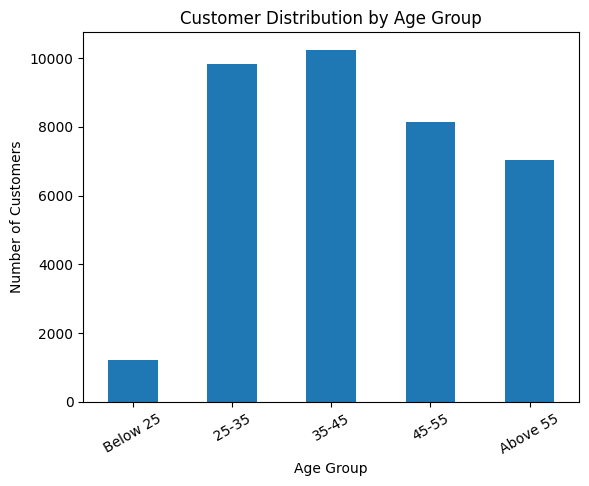

In [8]:
# Visualize age group distribution
age_counts = fe_df['AGE_GROUP'].value_counts().sort_index()
age_counts.plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

## Step 7: Create Income Group Feature

Income is one of the most important columns in a credit approval project.

### Why are we doing this?

Instead of only using raw income, we create income groups to understand customers as low, medium, high, and very high income groups.

This helps the model capture risk patterns more clearly.

In [9]:
# Create income groups using quantiles
fe_df['INCOME_GROUP'] = pd.qcut(
    fe_df['AMT_INCOME_TOTAL'],
    q=4,
    labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income']
)

fe_df[['AMT_INCOME_TOTAL', 'INCOME_GROUP']].head()

,AMT_INCOME_TOTAL,INCOME_GROUP
0,427500.0,Very High Income
1,427500.0,Very High Income
2,112500.0,Low Income
3,270000.0,Very High Income
4,270000.0,Very High Income


## What does this graph tell us?

This graph compares the percentage of risky customers in each income group.

### Why is this useful?

If one income group has a higher target rate, it means that group may carry more credit risk. This gives the bank a useful business insight.

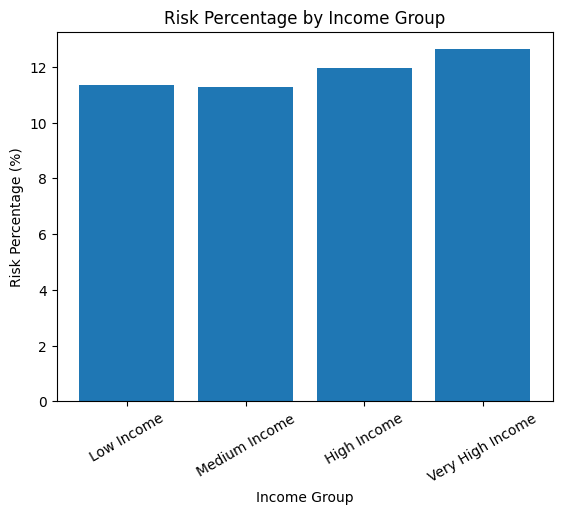

,INCOME_GROUP,TARGET
0,Low Income,11.348877
1,Medium Income,11.275900
2,High Income,11.950617
3,Very High Income,12.627108


In [10]:
# Calculate default/risk rate by income group
income_risk = fe_df.groupby('INCOME_GROUP', observed=True)['TARGET'].mean().reset_index()
income_risk['TARGET'] = income_risk['TARGET'] * 100

plt.bar(income_risk['INCOME_GROUP'].astype(str), income_risk['TARGET'])
plt.title('Risk Percentage by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Risk Percentage (%)')
plt.xticks(rotation=30)
plt.show()

income_risk

## Step 8: Create Family Responsibility Features

A customer's income alone is not enough. A person earning ₹3,00,000 with a family of 1 is different from a person earning ₹3,00,000 with a family of 5.

### Why are we doing this?

These features help us understand financial pressure:

- `INCOME_PER_FAMILY_MEMBER` tells income available per person.
- `FAMILY_SIZE_GROUP` explains whether the customer has a small or large family.
- `CHILDREN_GROUP` summarizes child responsibility.

In [12]:
# Recalculate income per family member safely
fe_df['INCOME_PER_FAMILY_MEMBER'] = fe_df['AMT_INCOME_TOTAL'] / fe_df['CNT_FAM_MEMBERS'].replace(0, 1)

# Create family size groups
fe_df['FAMILY_SIZE_GROUP'] = pd.cut(
    fe_df['CNT_FAM_MEMBERS'],
    bins=[0, 1, 3, 6, 20],
    labels=['Single', 'Small Family', 'Medium Family', 'Large Family']
)

# Create children group
fe_df['CHILDREN_GROUP'] = pd.cut(
    fe_df['CNT_CHILDREN'],
    bins=[-1, 0, 2, 20],
    labels=['No Children', '1-2 Children', 'More than 2 Children']
)

fe_df[['CNT_FAM_MEMBERS', 'FAMILY_SIZE_GROUP', 'CNT_CHILDREN', 'CHILDREN_GROUP', 'INCOME_PER_FAMILY_MEMBER']].head()

,CNT_FAM_MEMBERS,FAMILY_SIZE_GROUP,CNT_CHILDREN,CHILDREN_GROUP,INCOME_PER_FAMILY_MEMBER
0,2.0,Small Family,0,No Children,213750.0
1,2.0,Small Family,0,No Children,213750.0
2,2.0,Small Family,0,No Children,56250.0
3,1.0,Single,0,No Children,270000.0
4,1.0,Single,0,No Children,270000.0


## What does this graph tell us?

This graph shows the risk percentage for different family size groups.

### Why is this useful?

Family responsibility can affect repayment capacity. Larger families may have higher expenses, so this feature may help the ML model understand financial pressure.

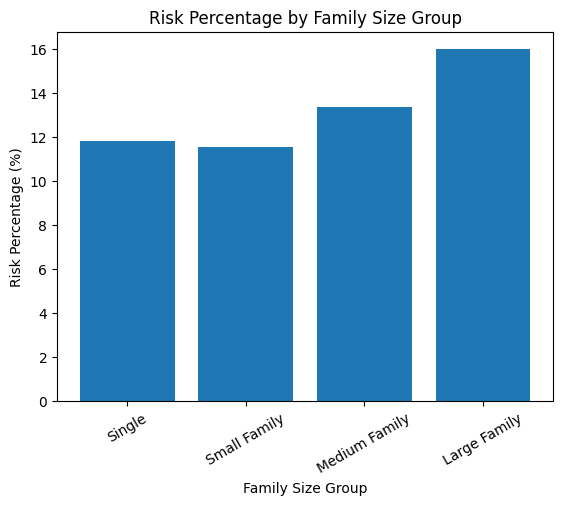

,FAMILY_SIZE_GROUP,TARGET
0,Single,11.807643
1,Small Family,11.536084
2,Medium Family,13.367032
3,Large Family,16.000000


In [13]:
# Risk percentage by family size group
family_risk = fe_df.groupby('FAMILY_SIZE_GROUP', observed=True)['TARGET'].mean().reset_index()
family_risk['TARGET'] = family_risk['TARGET'] * 100

plt.bar(family_risk['FAMILY_SIZE_GROUP'].astype(str), family_risk['TARGET'])
plt.title('Risk Percentage by Family Size Group')
plt.xlabel('Family Size Group')
plt.ylabel('Risk Percentage (%)')
plt.xticks(rotation=30)
plt.show()

family_risk

# Part 2: Employment Stability Features

The next part of our story is about customer stability.

A bank may think:

> A customer with longer employment history may be more financially stable.

So we create employment-related features.

## Step 9: Create Employment Group Feature

The cleaned dataset already contains `EMPLOYMENT_YEARS`. Now we convert it into easy-to-understand groups.

### Why are we doing this?

Employment groups help capture stability levels:

- newly employed,
- moderately experienced,
- highly experienced,
- unemployed or no work history.

In [14]:
# Create employment group categories
fe_df['EMPLOYMENT_GROUP'] = pd.cut(
    fe_df['EMPLOYMENT_YEARS'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['Not Employed', '0-2 Years', '2-5 Years', '5-10 Years', 'Above 10 Years']
)

# Create employed flag
fe_df['IS_EMPLOYED'] = np.where(fe_df['EMPLOYMENT_YEARS'] > 0, 1, 0)

# Employment stability ratio
fe_df['EMPLOYMENT_TO_AGE_RATIO'] = fe_df['EMPLOYMENT_YEARS'] / fe_df['AGE'].replace(0, 1)

fe_df[['EMPLOYMENT_YEARS', 'EMPLOYMENT_GROUP', 'IS_EMPLOYED', 'EMPLOYMENT_TO_AGE_RATIO']].head()

,EMPLOYMENT_YEARS,EMPLOYMENT_GROUP,IS_EMPLOYED,EMPLOYMENT_TO_AGE_RATIO
0,12,Above 10 Years,1,0.375000
1,12,Above 10 Years,1,0.375000
2,3,2-5 Years,1,0.051724
3,8,5-10 Years,1,0.153846
4,8,5-10 Years,1,0.153846


## What does this graph tell us?

This graph compares risky customers across employment groups.

### Why is this useful?

If customers with very short work experience show higher risk, employment history can become an important feature for the ML model.

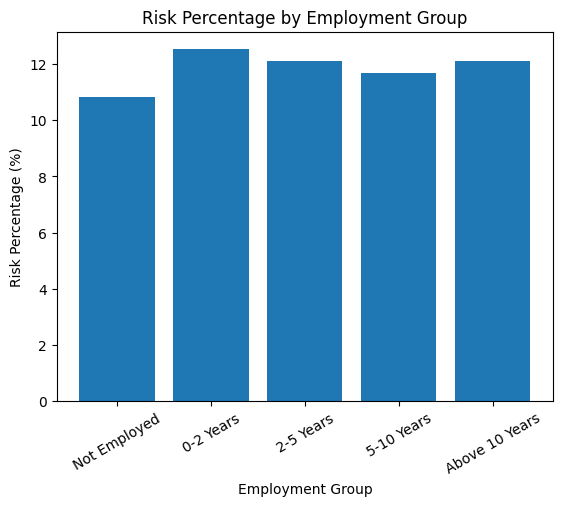

,EMPLOYMENT_GROUP,TARGET
0,Not Employed,10.812680
1,0-2 Years,12.520840
2,2-5 Years,12.089610
3,5-10 Years,11.693195
4,Above 10 Years,12.090096


In [15]:
# Risk percentage by employment group
employment_risk = fe_df.groupby('EMPLOYMENT_GROUP', observed=True)['TARGET'].mean().reset_index()
employment_risk['TARGET'] = employment_risk['TARGET'] * 100

plt.bar(employment_risk['EMPLOYMENT_GROUP'].astype(str), employment_risk['TARGET'])
plt.title('Risk Percentage by Employment Group')
plt.xlabel('Employment Group')
plt.ylabel('Risk Percentage (%)')
plt.xticks(rotation=30)
plt.show()

employment_risk

# Part 3: Asset and Contact Features

The next part of the customer story is about assets and reachability.

A bank may ask:

> Does the customer own a car or property?  
> Can the customer be easily contacted?

These are not perfect risk indicators, but they can add useful supporting information.

## Step 10: Create Asset Ownership Features

We convert car and property ownership from text values into numeric values.

### Why are we doing this?

Machine learning models do not understand `Y` and `N` directly. So we convert them into:

- 1 = Yes
- 0 = No

Then we create `ASSET_SCORE`, which tells how many major assets the customer owns.

In [16]:
# Convert asset ownership columns into numeric flags
fe_df['OWN_CAR_FLAG'] = fe_df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
fe_df['OWN_REALTY_FLAG'] = fe_df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

# Asset score: car + property
fe_df['ASSET_SCORE'] = fe_df['OWN_CAR_FLAG'] + fe_df['OWN_REALTY_FLAG']

fe_df[['FLAG_OWN_CAR', 'OWN_CAR_FLAG', 'FLAG_OWN_REALTY', 'OWN_REALTY_FLAG', 'ASSET_SCORE']].head()

,FLAG_OWN_CAR,OWN_CAR_FLAG,FLAG_OWN_REALTY,OWN_REALTY_FLAG,ASSET_SCORE
0,Y,1,Y,1,2
1,Y,1,Y,1,2
2,Y,1,Y,1,2
3,N,0,Y,1,1
4,N,0,Y,1,1


## What does this graph tell us?

This graph compares risk percentage based on asset score.

### Why is this useful?

Customers with more assets may have stronger financial background. This feature may help the model understand financial security.

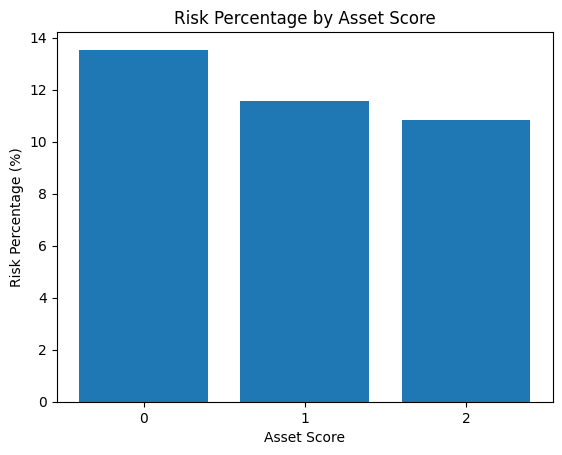

,ASSET_SCORE,TARGET
0,0,13.530946
1,1,11.560202
2,2,10.829066


In [17]:
# Risk percentage by asset score
asset_risk = fe_df.groupby('ASSET_SCORE')['TARGET'].mean().reset_index()
asset_risk['TARGET'] = asset_risk['TARGET'] * 100

plt.bar(asset_risk['ASSET_SCORE'].astype(str), asset_risk['TARGET'])
plt.title('Risk Percentage by Asset Score')
plt.xlabel('Asset Score')
plt.ylabel('Risk Percentage (%)')
plt.show()

asset_risk

## Step 11: Create Contact Availability Score

The dataset has contact-related columns such as work phone, phone, and email.

### Why are we doing this?

A customer who provides more contact options may be easier for the bank to reach. So we combine these columns into one simple score.

In [18]:
# Create contact availability score
fe_df['CONTACT_SCORE'] = fe_df['FLAG_WORK_PHONE'] + fe_df['FLAG_PHONE'] + fe_df['FLAG_EMAIL']

fe_df[['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CONTACT_SCORE']].head()

,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CONTACT_SCORE
0,1,0,0,1
1,1,0,0,1
2,0,0,0,0
3,0,1,1,2
4,0,1,1,2


# Part 4: Credit Behaviour Features

This is the most powerful part of the story.

Customer profile tells us who the customer is.  
Credit history tells us how the customer behaves with payments.

So we create features based on repayment behaviour.

## Step 12: Create Payment Behaviour Ratios

The cleaned dataset already contains:

- `TOTAL_MONTHS`
- `MONTHS_ON_TIME`
- `MONTHS_DELAYED`
- `MAX_DELAY_STATUS`

Now we create percentage-based features.

### Why are we doing this?

A customer with 2 delayed months out of 3 months is more risky than a customer with 2 delayed months out of 30 months.  
So ratios give a fairer view of customer behaviour.

In [19]:
# Create payment behaviour ratios safely
fe_df['ON_TIME_PAYMENT_RATIO'] = fe_df['MONTHS_ON_TIME'] / fe_df['TOTAL_MONTHS'].replace(0, 1)
fe_df['DELAYED_PAYMENT_RATIO'] = fe_df['MONTHS_DELAYED'] / fe_df['TOTAL_MONTHS'].replace(0, 1)

# Create high delay flag
fe_df['HAS_HIGH_DELAY'] = np.where(fe_df['MAX_DELAY_STATUS'] >= 2, 1, 0)

fe_df[['TOTAL_MONTHS', 'MONTHS_ON_TIME', 'MONTHS_DELAYED', 'ON_TIME_PAYMENT_RATIO', 'DELAYED_PAYMENT_RATIO', 'MAX_DELAY_STATUS', 'HAS_HIGH_DELAY']].head()

,TOTAL_MONTHS,MONTHS_ON_TIME,MONTHS_DELAYED,ON_TIME_PAYMENT_RATIO,DELAYED_PAYMENT_RATIO,MAX_DELAY_STATUS,HAS_HIGH_DELAY
0,16,15,1,0.937500,0.062500,1,0
1,15,14,1,0.933333,0.066667,1,0
2,30,30,0,1.000000,0.000000,0,0
3,5,5,0,1.000000,0.000000,0,0
4,5,5,0,1.000000,0.000000,0,0


## What does this graph tell us?

This boxplot compares delayed payment ratio for good and risky customers.

### Why is this useful?

If risky customers have higher delayed payment ratio, then this feature is very useful for machine learning.

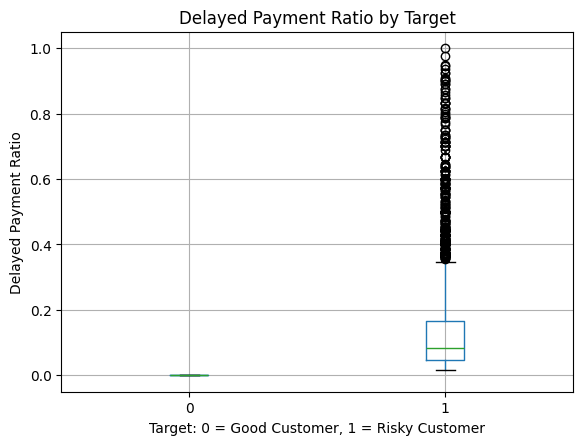

In [20]:
# Compare delayed payment ratio with target
fe_df.boxplot(column='DELAYED_PAYMENT_RATIO', by='TARGET')
plt.title('Delayed Payment Ratio by Target')
plt.suptitle('')
plt.xlabel('Target: 0 = Good Customer, 1 = Risky Customer')
plt.ylabel('Delayed Payment Ratio')
plt.show()

## Step 13: Create Credit History Strength Feature

Customers with longer credit history give us more information about their repayment behaviour.

### Why are we doing this?

A customer with many months of record may be easier to judge than a customer with very few months of history.

In [21]:
# Create credit history strength groups
fe_df['CREDIT_HISTORY_STRENGTH'] = pd.cut(
    fe_df['TOTAL_MONTHS'],
    bins=[0, 6, 12, 24, 100],
    labels=['Very Short', 'Short', 'Medium', 'Long']
)

fe_df[['TOTAL_MONTHS', 'CREDIT_HISTORY_STRENGTH']].head()

,TOTAL_MONTHS,CREDIT_HISTORY_STRENGTH
0,16,Medium
1,15,Medium
2,30,Long
3,5,Very Short
4,5,Very Short


## What does this graph tell us?

This graph shows risk percentage based on credit history strength.

### Why is this useful?

It helps us check whether customers with shorter or longer credit history behave differently.

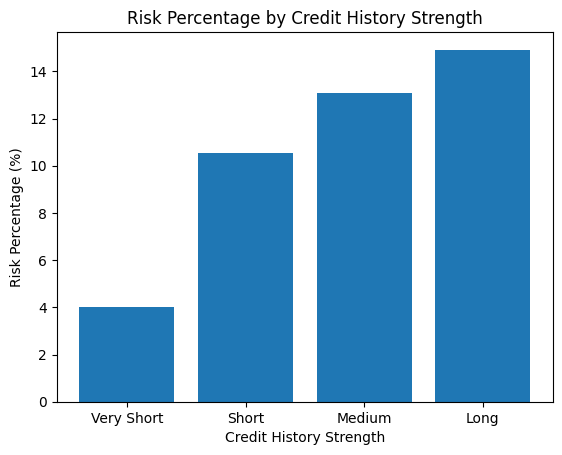

,CREDIT_HISTORY_STRENGTH,TARGET
0,Very Short,4.004038
1,Short,10.544122
2,Medium,13.082018
3,Long,14.916749


In [22]:
# Risk percentage by credit history strength
history_risk = fe_df.groupby('CREDIT_HISTORY_STRENGTH', observed=True)['TARGET'].mean().reset_index()
history_risk['TARGET'] = history_risk['TARGET'] * 100

plt.bar(history_risk['CREDIT_HISTORY_STRENGTH'].astype(str), history_risk['TARGET'])
plt.title('Risk Percentage by Credit History Strength')
plt.xlabel('Credit History Strength')
plt.ylabel('Risk Percentage (%)')
plt.show()

history_risk

# Part 5: Encoding Features for Machine Learning

Now our dataset has both numeric and text/category columns.

Machine learning models cannot directly understand text categories like `Married`, `Working`, or `Higher education`.

So we convert categorical columns into numeric format.

## Step 14: Encode Gender and Education

Some columns can be encoded manually.

### Why are we doing this?

- Gender has two main values, so we map it into 0 and 1.
- Education has a natural order, so we assign increasing numbers based on education level.

In [23]:
# Encode gender
fe_df['GENDER_MALE'] = fe_df['CODE_GENDER'].map({'F': 0, 'M': 1})

# Encode education in meaningful order
education_order = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}

fe_df['EDUCATION_LEVEL'] = fe_df['NAME_EDUCATION_TYPE'].map(education_order)

fe_df[['CODE_GENDER', 'GENDER_MALE', 'NAME_EDUCATION_TYPE', 'EDUCATION_LEVEL']].head()

,CODE_GENDER,GENDER_MALE,NAME_EDUCATION_TYPE,EDUCATION_LEVEL
0,M,1,Higher education,4
1,M,1,Higher education,4
2,M,1,Secondary / secondary special,2
3,F,0,Secondary / secondary special,2
4,F,0,Secondary / secondary special,2


## Step 15: Encode Ordered Group Features

Some groups have a clear order.

### Why are we doing this?

For example, income group has an order:

Low Income < Medium Income < High Income < Very High Income

So we encode these groups using numbers while keeping their meaning.

In [24]:
# Ordered encoding for grouped features
age_group_order = {
    'Below 25': 1,
    '25-35': 2,
    '35-45': 3,
    '45-55': 4,
    'Above 55': 5
}

income_group_order = {
    'Low Income': 1,
    'Medium Income': 2,
    'High Income': 3,
    'Very High Income': 4
}

family_group_order = {
    'Single': 1,
    'Small Family': 2,
    'Medium Family': 3,
    'Large Family': 4
}

children_group_order = {
    'No Children': 0,
    '1-2 Children': 1,
    'More than 2 Children': 2
}

employment_group_order = {
    'Not Employed': 0,
    '0-2 Years': 1,
    '2-5 Years': 2,
    '5-10 Years': 3,
    'Above 10 Years': 4
}

credit_history_order = {
    'Very Short': 1,
    'Short': 2,
    'Medium': 3,
    'Long': 4
}

fe_df['AGE_GROUP_ENCODED'] = fe_df['AGE_GROUP'].astype(str).map(age_group_order)
fe_df['INCOME_GROUP_ENCODED'] = fe_df['INCOME_GROUP'].astype(str).map(income_group_order)
fe_df['FAMILY_SIZE_GROUP_ENCODED'] = fe_df['FAMILY_SIZE_GROUP'].astype(str).map(family_group_order)
fe_df['CHILDREN_GROUP_ENCODED'] = fe_df['CHILDREN_GROUP'].astype(str).map(children_group_order)
fe_df['EMPLOYMENT_GROUP_ENCODED'] = fe_df['EMPLOYMENT_GROUP'].astype(str).map(employment_group_order)
fe_df['CREDIT_HISTORY_STRENGTH_ENCODED'] = fe_df['CREDIT_HISTORY_STRENGTH'].astype(str).map(credit_history_order)

fe_df[['AGE_GROUP', 'AGE_GROUP_ENCODED', 'INCOME_GROUP', 'INCOME_GROUP_ENCODED', 'CREDIT_HISTORY_STRENGTH', 'CREDIT_HISTORY_STRENGTH_ENCODED']].head()

,AGE_GROUP,AGE_GROUP_ENCODED,INCOME_GROUP,INCOME_GROUP_ENCODED,CREDIT_HISTORY_STRENGTH,CREDIT_HISTORY_STRENGTH_ENCODED
0,25-35,2,Very High Income,4,Medium,3
1,25-35,2,Very High Income,4,Medium,3
2,Above 55,5,Low Income,1,Long,4
3,45-55,4,Very High Income,4,Very Short,1
4,45-55,4,Very High Income,4,Very Short,1


## Step 16: One-Hot Encode Text Columns

Some categorical columns do not have a natural order.

Examples:

- income type,
- family status,
- housing type,
- occupation type.

### Why are we doing this?

We use one-hot encoding because these categories are names, not rankings.  
For example, `Married` is not greater than `Single`, so we should not assign fake ranking numbers.

In [25]:
# Select categorical columns for one-hot encoding
categorical_cols = [
    'NAME_INCOME_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

# Apply one-hot encoding
fe_encoded = pd.get_dummies(fe_df, columns=categorical_cols, drop_first=False, dtype=int)

print('One-hot encoding completed!')
print('Columns before encoding:', fe_df.shape[1])
print('Columns after encoding:', fe_encoded.shape[1])

One-hot encoding completed!
Columns before encoding: 50
Columns after encoding: 81


# Part 6: Preparing Final ML Dataset

Now we have created many useful features.  
But the dataset still contains some raw text columns and ID columns.

Before machine learning, we need a clean numeric dataset.

## Step 17: Drop Raw and Redundant Columns

We remove columns that are not useful for direct machine learning.

### Why are we doing this?

- `ID` is only an identifier, not a learning feature.
- Raw text columns are already encoded.
- Some raw date columns are already converted into better features.
- String group columns are already converted into numeric encoded columns.

This makes the final dataset clean and ML-ready.

In [26]:
# Columns to drop before ML
columns_to_drop = [
    'ID',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_EDUCATION_TYPE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'AGE_GROUP',
    'INCOME_GROUP',
    'FAMILY_SIZE_GROUP',
    'CHILDREN_GROUP',
    'EMPLOYMENT_GROUP',
    'CREDIT_HISTORY_STRENGTH'
]

# Drop only columns that exist
columns_to_drop = [col for col in columns_to_drop if col in fe_encoded.columns]

ml_df = fe_encoded.drop(columns=columns_to_drop)

print('Raw and redundant columns removed!')
print('Final shape:', ml_df.shape)

Raw and redundant columns removed!
Final shape: (36457, 68)


## Step 18: Check Missing Values After Feature Engineering

Sometimes new features can create missing values.

### Why are we doing this?

Before sending data to ML models, we must make sure there are no missing values or infinite values.

In [27]:
# Check missing values
missing_values = ml_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print('No missing values found!')
else:
    print('Missing values found:')
    print(missing_values)
    ml_df = ml_df.fillna(0)
    print('Missing values filled with 0.')

# Replace infinite values if any
ml_df = ml_df.replace([np.inf, -np.inf], 0)

No missing values found!


## Step 19: Check Final Data Types

Now we confirm whether the final dataset is numeric.

### Why are we doing this?

Most machine learning algorithms need numeric input. If object/text columns are still present, the model may give errors.

In [28]:
# Check remaining object columns
object_columns = ml_df.select_dtypes(include='object').columns.tolist()

if len(object_columns) == 0:
    print('All columns are numeric and ready for ML!')
else:
    print('Object columns still present:')
    print(object_columns)

ml_df.dtypes.head(20)

All columns are numeric and ready for ML!


CNT_CHILDREN                  int64
AMT_INCOME_TOTAL            float64
FLAG_MOBIL                    int64
FLAG_WORK_PHONE               int64
FLAG_PHONE                    int64
FLAG_EMAIL                    int64
CNT_FAM_MEMBERS             float64
TARGET                        int64
TOTAL_MONTHS                  int64
MONTHS_ON_TIME                int64
MONTHS_DELAYED                int64
MAX_DELAY_STATUS              int64
AGE                           int64
EMPLOYMENT_YEARS              int64
INCOME_PER_FAMILY_MEMBER    float64
HAS_CHILDREN                  int64
IS_EMPLOYED                   int64
EMPLOYMENT_TO_AGE_RATIO     float64
OWN_CAR_FLAG                  int64
OWN_REALTY_FLAG               int64
dtype: object

## Step 20: Preview Correlation with Target

Before machine learning, we take a quick look at which features are most related to the target.

### Why are we doing this?

This is not the final feature importance.  
But it gives us an early idea of which engineered features may be useful for prediction.

In [29]:
# Correlation of numeric features with TARGET
correlation = ml_df.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

top_features = correlation.head(15)

top_features

MAX_DELAY_STATUS                   0.805710
DELAYED_PAYMENT_RATIO              0.664331
ON_TIME_PAYMENT_RATIO             -0.664331
MONTHS_DELAYED                     0.567493
HAS_HIGH_DELAY                     0.358938
CREDIT_HISTORY_STRENGTH_ENCODED    0.111494
TOTAL_MONTHS                       0.102934
MONTHS_ON_TIME                     0.044989
AGE_GROUP_ENCODED                 -0.030783
AGE                               -0.029115
OWN_REALTY_FLAG                   -0.027990
ASSET_SCORE                       -0.027273
AMT_INCOME_TOTAL                   0.024202
OCCUPATION_TYPE_Unknown           -0.024046
GENDER_MALE                        0.021257
Name: TARGET, dtype: float64

## What does this graph tell us?

This graph shows the top features that have the strongest relationship with the target column.

### Why is this useful?

It helps us check whether our newly created features are adding useful signals for machine learning.

Positive correlation means the feature may increase risk.  
Negative correlation means the feature may reduce risk.

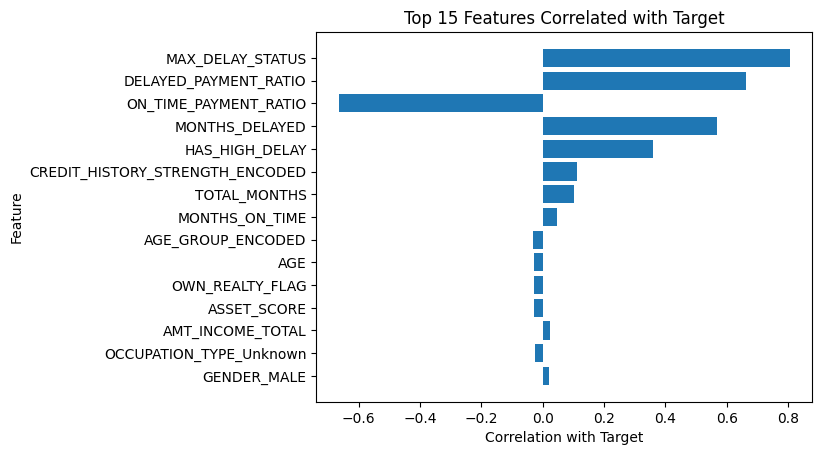

In [32]:
# Plot top correlated features
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.title('Top 15 Features Correlated with Target')
plt.xlabel('Correlation with Target')
plt.ylabel('Feature')
plt.show()

## Step 21: Save the Feature-Engineered Dataset

Now we save the final dataset.

### Why are we doing this?

The next notebook will be machine learning analysis.  
Instead of repeating feature engineering again, we save this final dataset and directly use it for model training.

In [31]:
# Save final feature engineered dataset
ml_df.to_csv('feature_engineered_credit_card_data.csv', index=False)

print('Feature-engineered dataset saved successfully!')
print('File name: feature_engineered_credit_card_data.csv')
print('Rows:', ml_df.shape[0])
print('Columns:', ml_df.shape[1])

Feature-engineered dataset saved successfully!
File name: feature_engineered_credit_card_data.csv
Rows: 36457
Columns: 68


# Conclusion

In this notebook, we completed the feature engineering phase of the Credit Card Approval project.

### What we did

We created meaningful features from raw customer and credit history data:

- Age group
- Income group
- Family size group
- Children group
- Employment group
- Income per family member
- Employment to age ratio
- Asset score
- Contact score
- On-time payment ratio
- Delayed payment ratio
- High delay flag
- Credit history strength
- Gender encoding
- Education level encoding
- One-hot encoded categorical columns

### Storytelling summary

At the beginning, our dataset was like a customer file with many raw details.  
By the end, we transformed it into a machine-learning-ready table where every column gives useful information about customer risk.

Now the bank can use this final dataset to train models that predict whether a customer is likely to be good or risky for credit card approval.

The next step is:

> **Machine Learning Analysis — train models, compare performance, and select the best model.**